# EEG-Based Mental Stress Detection

**Course:** Data Science Capstone Project

**Authors:** AGAFONOVA Yoana, HRISTOVA Iliana

**Goal:** Detect mental stress from EEG recordings using machine learning and binary classification.

This notebook contains the complete workflow used in the project:

1. Dataset loading and label creation
2. Exploratory Data Analysis (EDA)
3. EEG preprocessing and visualization
4. Feature extraction from full recordings
5. Baseline model training
6. Window-based feature extraction
7. Group-based validation
8. Final model evaluation and feature importance

The notebook is designed to be reproducible. The dataset should be placed in the `../data/` folder and the outputs are saved in `../outputs/plots/` and `../outputs/results/`.

## 1. Imports and Setup

This section imports all libraries used for loading EDF files, preprocessing EEG signals, extracting features, training models, and saving results.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.signal import welch

from sklearn.model_selection import (
    StratifiedKFold,
    GroupKFold,
    GroupShuffleSplit,
    cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import mne

# Create output folders if they do not already exist.
os.makedirs("../outputs/plots", exist_ok=True)
os.makedirs("../outputs/results", exist_ok=True)

# Main dataset folder. The notebook is located in /notebooks, so ../data points to the project data folder.
DATA_DIR = "../data"

print("Setup completed.")

Setup completed.


## 2. Dataset Loading and Label Creation

The dataset is organized into folders according to the experimental condition.
Four conditions are treated as **stress**, while the relaxing music condition is treated as **non-stress**.

**Stress conditions:**
- Complex Mathematical Problem solving (CMPS)
- Horrer Video Stimulation
- Stroop Colour Word Test(SCWT)
- Trier Mental Challenge Test (TMCT)

**Non-stress condition:**
- Participants Listening to Relaxing Music

In [2]:
# Check how many EDF files are present in each condition folder.
for root, dirs, files in os.walk(DATA_DIR):
    edf_files = [f for f in files if f.lower().endswith(".edf")]
    if edf_files:
        print(root, "->", len(edf_files), "EDF files")

../data\Complex Mathematical Problem solving (CMPS) -> 22 EDF files
../data\Horrer Video Stimulation -> 22 EDF files
../data\Participants Listening to Relaxing Music -> 20 EDF files
../data\Stroop Colour Word Test(SCWT) -> 24 EDF files
../data\Trier Mental Challenge Test (TMCT) -> 24 EDF files


In [3]:
# Create a table containing the file paths, condition names, and class labels.
records = []

label_map = {
    "Complex Mathematical Problem solving (CMPS)": 1,
    "Horrer Video Stimulation": 1,
    "Stroop Colour Word Test(SCWT)": 1,
    "Trier Mental Challenge Test (TMCT)": 1,
    "Participants Listening to Relaxing Music": 0
}

condition_map = {
    "Complex Mathematical Problem solving (CMPS)": "CMPS",
    "Horrer Video Stimulation": "Horror",
    "Stroop Colour Word Test(SCWT)": "SCWT",
    "Trier Mental Challenge Test (TMCT)": "TMCT",
    "Participants Listening to Relaxing Music": "Relaxing Music"
}

for folder_name, label in label_map.items():
    folder_path = os.path.join(DATA_DIR, folder_name)

    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(".edf"):
            records.append({
                "file_path": os.path.join(folder_path, file_name),
                "file_name": file_name,
                "condition": condition_map[folder_name],
                "label": label,
                "label_name": "Stress" if label == 1 else "Non-stress"
            })

df_files = pd.DataFrame(records)

print("Dataset file table shape:", df_files.shape)
df_files.head()

Dataset file table shape: (112, 5)


,file_path,file_name,condition,label,label_name
0,../data\Complex Mathematical Problem solving (...,1 (1).edf,CMPS,1,Stress
1,../data\Complex Mathematical Problem solving (...,1 (10).edf,CMPS,1,Stress
2,../data\Complex Mathematical Problem solving (...,1 (11).edf,CMPS,1,Stress
3,../data\Complex Mathematical Problem solving (...,1 (12).edf,CMPS,1,Stress
4,../data\Complex Mathematical Problem solving (...,1 (13).edf,CMPS,1,Stress


## 3. Exploratory Data Analysis (EDA)

The first EDA step checks the distribution of classes and experimental conditions.
This is important because the dataset is imbalanced: there are more stress recordings than non-stress recordings.

In [4]:
# Class distribution at EDF-file level.
df_files["label_name"].value_counts()

label_name
Stress        92
Non-stress    20
Name: count, dtype: int64

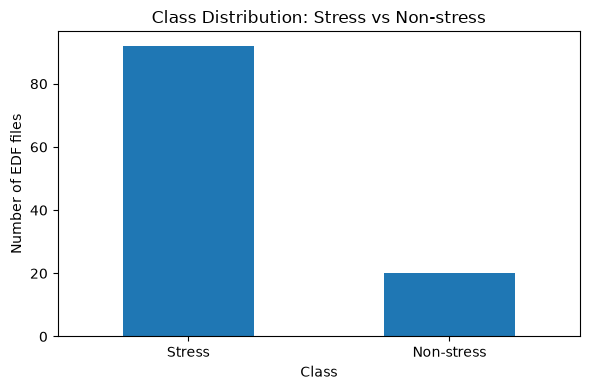

In [5]:
# Plot class distribution.
plt.figure(figsize=(6, 4))
df_files["label_name"].value_counts().plot(kind="bar")
plt.title("Class Distribution: Stress vs Non-stress")
plt.xlabel("Class")
plt.ylabel("Number of EDF files")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/plots/class_distribution.png", dpi=300)
plt.show()

In [6]:
# Condition distribution at EDF-file level.
df_files["condition"].value_counts()

condition
SCWT              24
TMCT              24
CMPS              22
Horror            22
Relaxing Music    20
Name: count, dtype: int64

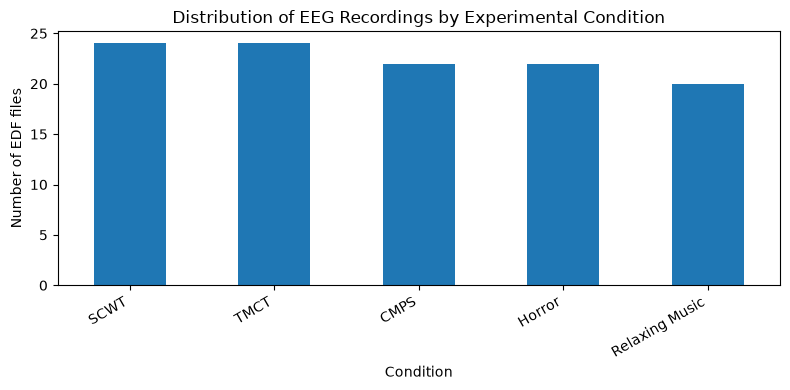

In [7]:
# Plot distribution by experimental condition.
plt.figure(figsize=(8, 4))
df_files["condition"].value_counts().plot(kind="bar")
plt.title("Distribution of EEG Recordings by Experimental Condition")
plt.xlabel("Condition")
plt.ylabel("Number of EDF files")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../outputs/plots/condition_distribution.png", dpi=300)
plt.show()

## 4. Inspecting and Visualizing EEG Signals

The EDF files contain EEG channels as well as metadata and quality channels.
Only the five EEG channels used in the project are selected:

`AF3`, `T7`, `Pz`, `T8`, `AF4`

The signals are converted to microvolts for easier visualization.

In [8]:
# Open one sample EDF file to inspect the structure.
sample_file = df_files.iloc[0]["file_path"]
raw = mne.io.read_raw_edf(sample_file, preload=True, verbose=False)

print("Sample file:", sample_file)
print("Sampling frequency:", raw.info["sfreq"])
print("Available channels:")
print(raw.ch_names)
print("Duration in seconds:", raw.times[-1])

Sample file: ../data\Complex Mathematical Problem solving (CMPS)\1 (1).edf
Sampling frequency: 128.0
Available channels:
['TIME_STAMP_s', 'TIME_STAMP_ms', 'OR_TIME_STAMP_s', 'OR_TIME_STAMP_ms', 'COUNTER', 'INTERPOLATED', 'AF3', 'T7', 'Pz', 'T8', 'AF4', 'RAW_CQ', 'BATTERY', 'BATTERY_PERCENT', 'MarkerIndex', 'MarkerType', 'MarkerValueInt', 'MARKER_HARDWARE', 'CQ_AF3', 'CQ_T7', 'CQ_Pz', 'CQ_T8', 'CQ_AF4', 'CQ_OVERALL', 'EQ_SampleRateQua', 'EQ_OVERALL', 'EQ_AF3', 'EQ_T7', 'EQ_Pz', 'EQ_T8', 'EQ_AF4']
Duration in seconds: 227.9921875


In [9]:
# Select only the EEG channels used for modeling.
EEG_CHANNELS = ["AF3", "T7", "Pz", "T8", "AF4"]

raw_eeg = raw.copy().pick(EEG_CHANNELS)

print("Selected EEG channels:")
print(raw_eeg.ch_names)

print("Data shape: channels x samples")
print(raw_eeg.get_data().shape)

Selected EEG channels:
['AF3', 'T7', 'Pz', 'T8', 'AF4']
Data shape: channels x samples
(5, 29184)


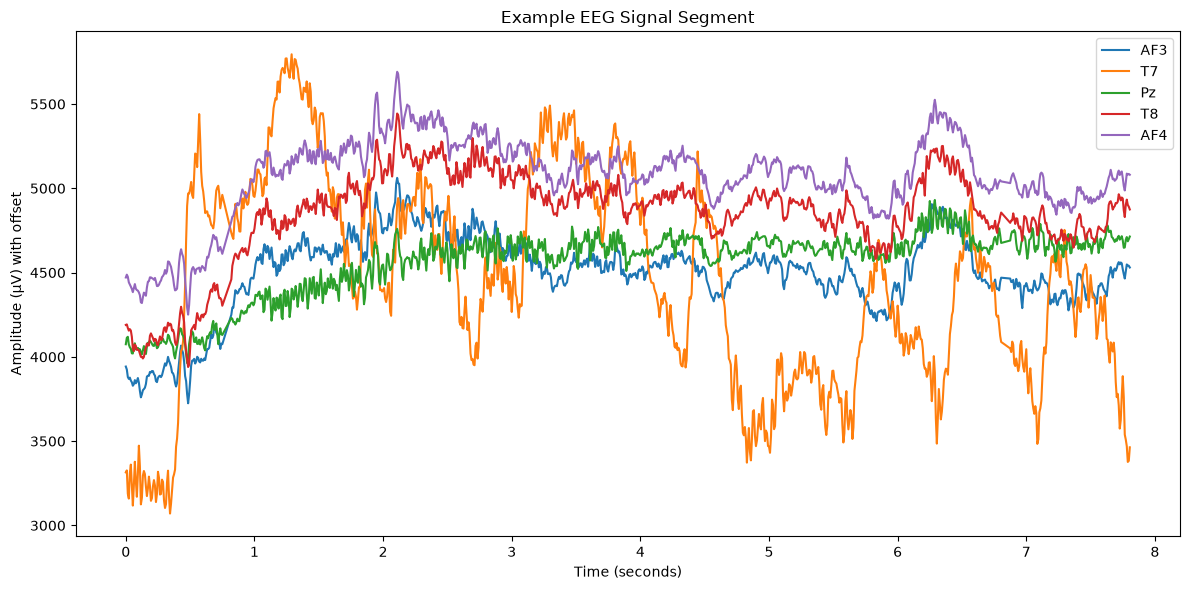

In [10]:
# Plot a short raw EEG segment in microvolts.
data, times = raw_eeg.get_data(return_times=True)

# MNE reads the data in volts, so we convert to microvolts.
data_uv = data * 1e6

plt.figure(figsize=(12, 6))
offset = 150

for i, channel in enumerate(EEG_CHANNELS):
    plt.plot(times[:1000], data_uv[i, :1000] + i * offset, label=channel)

plt.title("Example EEG Signal Segment")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV) with offset")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../outputs/plots/example_eeg_signal.png", dpi=300)
plt.show()

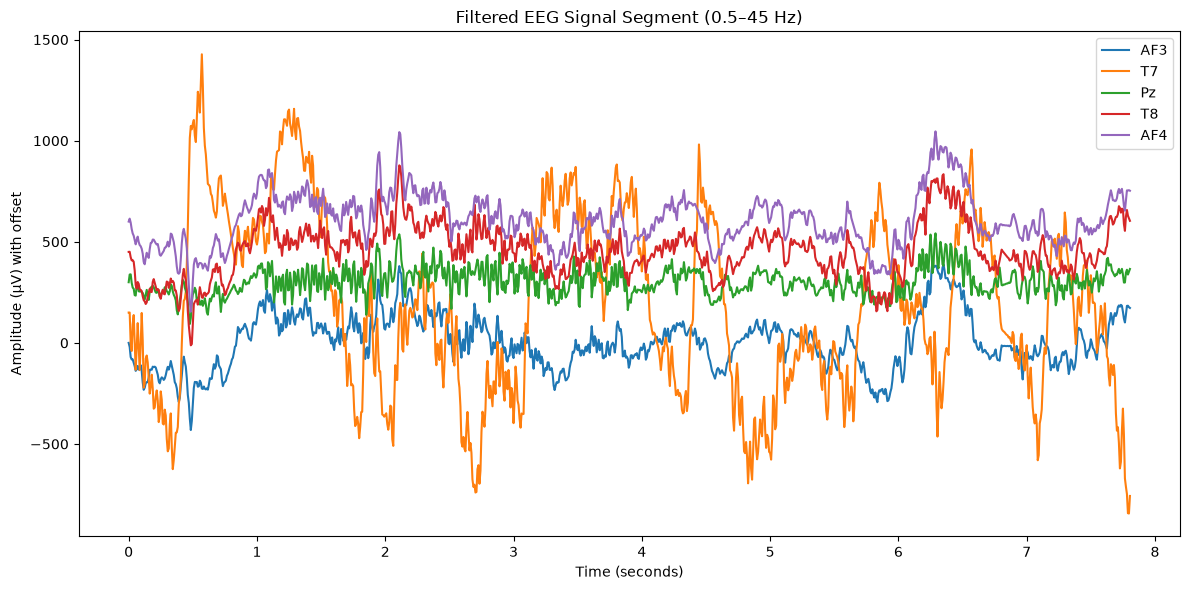

In [11]:
# Apply a bandpass filter and plot the filtered EEG signal.
# The filter removes slow baseline drift and high-frequency noise.
raw_filtered = raw_eeg.copy().filter(
    l_freq=0.5,
    h_freq=45,
    verbose=False
)

filtered_data, filtered_times = raw_filtered.get_data(return_times=True)
filtered_data_uv = filtered_data * 1e6

plt.figure(figsize=(12, 6))
offset = 150

for i, channel in enumerate(EEG_CHANNELS):
    plt.plot(filtered_times[:1000], filtered_data_uv[i, :1000] + i * offset, label=channel)

plt.title("Filtered EEG Signal Segment (0.5–45 Hz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV) with offset")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../outputs/plots/filtered_eeg_signal.png", dpi=300)
plt.show()

## 5. Feature Extraction from Full Recordings

For each EEG channel, the notebook extracts statistical and frequency-domain features.

**Statistical features:** mean, standard deviation, variance, minimum, maximum, median, skewness, kurtosis, energy, and entropy.

**Frequency-domain features:** delta, theta, alpha, beta, and gamma band power.

This first feature extraction approach creates one feature row per EDF file. It is later used as a baseline.

In [12]:
def bandpower(signal, sfreq, band):
    """
    Compute average power of the signal in a specific frequency band.

    Parameters:
        signal: one-dimensional EEG signal
        sfreq: sampling frequency in Hz
        band: tuple containing lower and upper frequency limits

    Returns:
        Band power value computed from the power spectral density.
    """
    low, high = band
    freqs, psd = welch(signal, fs=sfreq, nperseg=min(256, len(signal)))
    idx_band = np.logical_and(freqs >= low, freqs <= high)
    return np.trapezoid(psd[idx_band], freqs[idx_band])


def signal_entropy(signal):
    """
    Compute a simple Shannon entropy estimate from the signal histogram.
    """
    hist, _ = np.histogram(signal, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist))


def extract_features_from_raw(raw_obj, eeg_channels):
    """
    Extract statistical and frequency-domain features from the selected EEG channels.
    One row of features is produced for one full EDF recording.
    """
    raw_selected = raw_obj.copy().pick(eeg_channels)

    # Apply the same preprocessing to all recordings.
    raw_selected.filter(l_freq=0.5, h_freq=45, verbose=False)

    sfreq = raw_selected.info["sfreq"]
    data = raw_selected.get_data() * 1e6  # Convert from volts to microvolts.

    features = {}

    bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
        "gamma": (30, 45)
    }

    for i, channel in enumerate(eeg_channels):
        signal = data[i]

        # Statistical features.
        features[f"{channel}_mean"] = np.mean(signal)
        features[f"{channel}_std"] = np.std(signal)
        features[f"{channel}_var"] = np.var(signal)
        features[f"{channel}_min"] = np.min(signal)
        features[f"{channel}_max"] = np.max(signal)
        features[f"{channel}_median"] = np.median(signal)
        features[f"{channel}_skew"] = skew(signal)
        features[f"{channel}_kurtosis"] = kurtosis(signal)
        features[f"{channel}_energy"] = np.sum(signal ** 2) / len(signal)
        features[f"{channel}_entropy"] = signal_entropy(signal)

        # Frequency band power features.
        for band_name, band_range in bands.items():
            features[f"{channel}_{band_name}_power"] = bandpower(signal, sfreq, band_range)

    return features

In [13]:
# Test feature extraction on one EDF recording.
sample_features = extract_features_from_raw(raw, EEG_CHANNELS)

print("Number of extracted features:", len(sample_features))

sample_features_df = pd.DataFrame([sample_features])
sample_features_df.head()

Number of extracted features: 75


,AF3_mean,AF3_std,AF3_var,AF3_min,AF3_max,AF3_median,AF3_skew,AF3_kurtosis,AF3_energy,AF3_entropy,...,AF4_median,AF4_skew,AF4_kurtosis,AF4_energy,AF4_entropy,AF4_delta_power,AF4_theta_power,AF4_alpha_power,AF4_beta_power,AF4_gamma_power
0,0.233351,487.893075,238039.652985,-3174.246371,4346.01776,-0.410682,-0.043655,11.63118,238039.707438,0.069756,...,5.160108,-0.792376,8.315369,215991.361084,0.090456,119044.836678,3998.864539,702.035921,775.494119,419.79698


In [14]:
# Extract features from every EDF recording.
all_features = []

for idx, row in df_files.iterrows():
    try:
        raw_file = mne.io.read_raw_edf(row["file_path"], preload=True, verbose=False)
        features = extract_features_from_raw(raw_file, EEG_CHANNELS)

        # Add metadata columns for interpretation and modeling.
        features["file_name"] = row["file_name"]
        features["condition"] = row["condition"]
        features["label"] = row["label"]
        features["label_name"] = row["label_name"]

        all_features.append(features)

        print(f"Processed {idx + 1}/{len(df_files)}: {row['file_name']}")

    except Exception as e:
        print(f"Error processing {row['file_name']}: {e}")

df_features = pd.DataFrame(all_features)

print("Final feature table shape:", df_features.shape)
df_features.head()

Processed 1/112: 1 (1).edf
Processed 2/112: 1 (10).edf
Processed 3/112: 1 (11).edf
Processed 4/112: 1 (12).edf
Processed 5/112: 1 (13).edf
Processed 6/112: 1 (14).edf
Processed 7/112: 1 (15).edf
Processed 8/112: 1 (16).edf
Processed 9/112: 1 (17).edf
Processed 10/112: 1 (18).edf
Processed 11/112: 1 (19).edf
Processed 12/112: 1 (2).edf
Processed 13/112: 1 (20).edf
Processed 14/112: 1 (21).edf
Processed 15/112: 1 (22).edf
Processed 16/112: 1 (3).edf
Processed 17/112: 1 (4).edf
Processed 18/112: 1 (5).edf
Processed 19/112: 1 (6).edf
Processed 20/112: 1 (7).edf
Processed 21/112: 1 (8).edf
Processed 22/112: 1 (9).edf
Processed 23/112: 002 (1).edf
Processed 24/112: 002 (10).edf
Processed 25/112: 002 (11).edf
Processed 26/112: 002 (12).edf
Processed 27/112: 002 (13).edf
Processed 28/112: 002 (14).edf
Processed 29/112: 002 (15).edf
Processed 30/112: 002 (16).edf
Processed 31/112: 002 (17).edf
Processed 32/112: 002 (18).edf
Processed 33/112: 002 (19).edf
Processed 34/112: 002 (2).edf
Processed 

,AF3_mean,AF3_std,AF3_var,AF3_min,AF3_max,AF3_median,AF3_skew,AF3_kurtosis,AF3_energy,AF3_entropy,...,AF4_entropy,AF4_delta_power,AF4_theta_power,AF4_alpha_power,AF4_beta_power,AF4_gamma_power,file_name,condition,label,label_name
0,0.233351,487.893075,238039.652985,-3174.246371,4346.017760,-0.410682,-0.043655,11.631180,238039.707438,0.069756,...,0.090456,119044.836678,3998.864539,702.035921,775.494119,419.796980,1 (1).edf,CMPS,1,Stress
1,-0.916395,146.196028,21373.278540,-1536.290593,1257.287154,-3.192749,-0.713230,33.717544,21374.118319,0.146932,...,0.143553,11601.817947,421.762526,99.553633,65.407638,25.932660,1 (10).edf,CMPS,1,Stress
2,0.119020,105.216403,11070.491466,-952.394150,988.688014,-3.991151,0.014249,7.265789,11070.505632,0.223045,...,0.180742,4372.330629,163.745187,79.873883,163.828454,23.590227,1 (11).edf,CMPS,1,Stress
3,-0.232794,160.202520,25664.847521,-1257.964948,1940.290132,-5.963180,1.507686,19.785751,25664.901714,0.138364,...,0.139914,15303.550169,765.184399,271.226588,216.971911,49.254116,1 (12).edf,CMPS,1,Stress
4,-1.045693,399.396982,159517.949485,-3217.170928,4767.405136,-8.524284,2.296574,33.959351,159519.042958,0.059567,...,0.055002,69093.679531,8926.642047,2670.577850,1869.423745,204.621191,1 (13).edf,CMPS,1,Stress


In [15]:
# Save the full-recording feature table.
df_features.to_csv("../outputs/results/eeg_features.csv", index=False)
print("Feature table saved to ../outputs/results/eeg_features.csv")

Feature table saved to ../outputs/results/eeg_features.csv


## 6. Baseline Model Training on Full-Recording Features

This section trains several classical machine learning models using one feature row per EDF file.
This is a baseline experiment. Because there are only 112 EDF files and the classes are imbalanced, the results are expected to be limited.

In [16]:
# Prepare features and labels for the baseline full-recording experiment.
metadata_cols = ["file_name", "condition", "label", "label_name"]

X = df_features.drop(columns=metadata_cols)
y = df_features["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:")
print(y.value_counts())

X shape: (112, 75)
y shape: (112,)
Class distribution:
label
1    92
0    20
Name: count, dtype: int64


In [17]:
# Define the models used throughout the project.
# Class weighting is used where supported to reduce the effect of class imbalance.
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),
    "SVM": SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [18]:
# Use macro metrics to evaluate both classes more fairly.
# zero_division=0 avoids warnings when a model predicts only one class.
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "Precision Macro": scores["test_precision_macro"].mean(),
        "Recall Macro": scores["test_recall_macro"].mean(),
        "F1 Macro": scores["test_f1_macro"].mean()
    })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="F1 Macro", ascending=False)

df_results

,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Logistic Regression,0.632806,0.502924,0.498694,0.502924,0.489310
1,Random Forest,0.715810,0.475146,0.466587,0.475146,0.461248
3,KNN,0.812253,0.494444,0.409806,0.494444,0.448132
2,SVM,0.590909,0.458041,0.460015,0.458041,0.440363
4,Gradient Boosting,0.670356,0.408187,0.393630,0.408187,0.399610


## 7. Window-Based Feature Extraction

To create a richer dataset, each EDF recording is split into **10-second windows**.
Features are extracted from each window instead of from the whole recording.

This gives many more samples and better represents changes in EEG activity over time.

In [19]:
def extract_window_features(data_window, sfreq, eeg_channels):
    """
    Extract statistical and frequency-domain features from one EEG window.

    Parameters:
        data_window: EEG data with shape channels x samples
        sfreq: sampling frequency in Hz
        eeg_channels: list of EEG channel names

    Returns:
        Dictionary of extracted features for one window.
    """
    features = {}

    bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
        "gamma": (30, 45)
    }

    for i, channel in enumerate(eeg_channels):
        signal = data_window[i]

        # Statistical features.
        features[f"{channel}_mean"] = np.mean(signal)
        features[f"{channel}_std"] = np.std(signal)
        features[f"{channel}_var"] = np.var(signal)
        features[f"{channel}_min"] = np.min(signal)
        features[f"{channel}_max"] = np.max(signal)
        features[f"{channel}_median"] = np.median(signal)
        features[f"{channel}_skew"] = skew(signal)
        features[f"{channel}_kurtosis"] = kurtosis(signal)
        features[f"{channel}_energy"] = np.sum(signal ** 2) / len(signal)
        features[f"{channel}_entropy"] = signal_entropy(signal)

        # Frequency band power features.
        for band_name, band_range in bands.items():
            features[f"{channel}_{band_name}_power"] = bandpower(signal, sfreq, band_range)

    return features


def extract_window_features_from_file(file_path, eeg_channels, window_seconds=10):
    """
    Load one EDF file, filter it, split it into fixed-length windows,
    and extract features from each window.
    """
    raw_obj = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    raw_selected = raw_obj.copy().pick(eeg_channels)
    raw_selected.filter(l_freq=0.5, h_freq=45, verbose=False)

    sfreq = raw_selected.info["sfreq"]
    data = raw_selected.get_data() * 1e6  # Convert to microvolts.

    window_size = int(window_seconds * sfreq)
    total_samples = data.shape[1]

    window_features = []

    for start in range(0, total_samples - window_size + 1, window_size):
        end = start + window_size
        data_window = data[:, start:end]

        features = extract_window_features(data_window, sfreq, eeg_channels)
        features["window_start_sec"] = start / sfreq
        features["window_end_sec"] = end / sfreq

        window_features.append(features)

    return window_features

In [20]:
# Extract 10-second window features from all EDF files.
all_window_features = []

for idx, row in df_files.iterrows():
    try:
        window_features = extract_window_features_from_file(
            row["file_path"],
            EEG_CHANNELS,
            window_seconds=10
        )

        for features in window_features:
            features["file_name"] = row["file_name"]
            features["condition"] = row["condition"]
            features["label"] = row["label"]
            features["label_name"] = row["label_name"]

            all_window_features.append(features)

        print(f"Processed {idx + 1}/{len(df_files)}: {row['file_name']} -> {len(window_features)} windows")

    except Exception as e:
        print(f"Error processing {row['file_name']}: {e}")

df_windows = pd.DataFrame(all_window_features)

print("Window feature table shape:", df_windows.shape)
df_windows.head()

Processed 1/112: 1 (1).edf -> 22 windows
Processed 2/112: 1 (10).edf -> 18 windows
Processed 3/112: 1 (11).edf -> 44 windows
Processed 4/112: 1 (12).edf -> 19 windows
Processed 5/112: 1 (13).edf -> 47 windows
Processed 6/112: 1 (14).edf -> 114 windows
Processed 7/112: 1 (15).edf -> 48 windows
Processed 8/112: 1 (16).edf -> 62 windows
Processed 9/112: 1 (17).edf -> 30 windows
Processed 10/112: 1 (18).edf -> 60 windows
Processed 11/112: 1 (19).edf -> 29 windows
Processed 12/112: 1 (2).edf -> 33 windows
Processed 13/112: 1 (20).edf -> 55 windows
Processed 14/112: 1 (21).edf -> 53 windows
Processed 15/112: 1 (22).edf -> 26 windows
Processed 16/112: 1 (3).edf -> 24 windows
Processed 17/112: 1 (4).edf -> 61 windows
Processed 18/112: 1 (5).edf -> 51 windows
Processed 19/112: 1 (6).edf -> 25 windows
Processed 20/112: 1 (7).edf -> 52 windows
Processed 21/112: 1 (8).edf -> 37 windows
Processed 22/112: 1 (9).edf -> 29 windows
Processed 23/112: 002 (1).edf -> 17 windows
Processed 24/112: 002 (10).

,AF3_mean,AF3_std,AF3_var,AF3_min,AF3_max,AF3_median,AF3_skew,AF3_kurtosis,AF3_energy,AF3_entropy,...,AF4_theta_power,AF4_alpha_power,AF4_beta_power,AF4_gamma_power,window_start_sec,window_end_sec,file_name,condition,label,label_name
0,2.044949,133.296649,17767.996717,-431.081163,400.455737,2.577597,0.042191,0.183095,17772.178532,0.543943,...,902.693362,452.550745,488.830117,158.008117,0.0,10.0,1 (1).edf,CMPS,1,Stress
1,-8.309244,153.005747,23410.758718,-391.001172,425.210394,-17.558344,0.198377,0.158236,23479.802251,0.563938,...,468.587685,136.840782,143.018084,80.449489,10.0,20.0,1 (1).edf,CMPS,1,Stress
2,5.773626,146.127607,21353.277510,-319.858232,493.359913,-7.380790,0.423865,-0.027139,21386.612267,0.563566,...,398.466716,200.553946,249.703202,135.145275,20.0,30.0,1 (1).edf,CMPS,1,Stress
3,1.413441,130.210085,16954.666131,-309.006412,349.285263,1.632897,0.064536,-0.539364,16956.663946,0.685161,...,400.681068,222.336078,237.037773,83.569650,30.0,40.0,1 (1).edf,CMPS,1,Stress
4,6.818819,251.842132,63424.459389,-668.086981,840.120338,-17.592686,0.421238,1.060737,63470.955685,0.327252,...,1986.408602,352.916603,214.684703,67.387415,40.0,50.0,1 (1).edf,CMPS,1,Stress


In [21]:
# Save the window-based feature table.
df_windows.to_csv("../outputs/results/eeg_window_features.csv", index=False)

print("Window-based feature table saved.")
print(df_windows["label_name"].value_counts())

Window-based feature table saved.
label_name
Stress        3037
Non-stress     470
Name: count, dtype: int64


## 8. Model Training on Window-Based Features

This experiment trains the same models on the 10-second window features.
Two validation strategies are used:

1. **Random StratifiedKFold:** randomly splits windows into folds.
2. **GroupKFold by EDF file:** keeps all windows from the same EDF file in the same fold.

The GroupKFold result is more realistic because it reduces leakage between training and testing data.

In [22]:
# Prepare window-based features and labels.
metadata_cols = [
    "file_name",
    "condition",
    "label",
    "label_name",
    "window_start_sec",
    "window_end_sec"
]

X_window = df_windows.drop(columns=metadata_cols)
y_window = df_windows["label"]

print("X_window shape:", X_window.shape)
print("y_window shape:", y_window.shape)
print("Class distribution:")
print(y_window.value_counts())

X_window shape: (3507, 75)
y_window shape: (3507,)
Class distribution:
label
1    3037
0     470
Name: count, dtype: int64


In [23]:
# Random window-based cross-validation.
# This gives an optimistic estimate because windows from the same EDF recording may appear in both train and test folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

window_results = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_window,
        y_window,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    window_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "Precision Macro": scores["test_precision_macro"].mean(),
        "Recall Macro": scores["test_recall_macro"].mean(),
        "F1 Macro": scores["test_f1_macro"].mean()
    })

df_window_results = pd.DataFrame(window_results)
df_window_results = df_window_results.sort_values(by="F1 Macro", ascending=False)

df_window_results

,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro
1,Random Forest,0.938693,0.837815,0.887710,0.837815,0.858715
4,Gradient Boosting,0.926149,0.779317,0.880024,0.779317,0.816869
3,KNN,0.889647,0.715981,0.767403,0.715981,0.735922
2,SVM,0.777010,0.749857,0.644575,0.749857,0.660554
0,Logistic Regression,0.727389,0.722106,0.617259,0.722106,0.617338


In [24]:
# GroupKFold validation by EDF file.
# This is more realistic because windows from the same recording are kept together.
groups = df_windows["file_name"]
group_cv = GroupKFold(n_splits=5)

group_results = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_window,
        y_window,
        cv=group_cv,
        groups=groups,
        scoring=scoring,
        return_train_score=False
    )

    group_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "Precision Macro": scores["test_precision_macro"].mean(),
        "Recall Macro": scores["test_recall_macro"].mean(),
        "F1 Macro": scores["test_f1_macro"].mean()
    })

df_group_results = pd.DataFrame(group_results)
df_group_results = df_group_results.sort_values(by="F1 Macro", ascending=False)

df_group_results

,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro
4,Gradient Boosting,0.865394,0.580895,0.675782,0.580895,0.592857
3,KNN,0.834862,0.556457,0.586540,0.556457,0.562457
2,SVM,0.702515,0.643058,0.568488,0.643058,0.561096
1,Random Forest,0.838855,0.538910,0.588408,0.538910,0.539744
0,Logistic Regression,0.654055,0.619983,0.549066,0.619983,0.522415


In [25]:
# Save model comparison tables.
df_window_results.to_csv("../outputs/results/model_comparison_window_random_cv.csv", index=False)
df_group_results.to_csv("../outputs/results/model_comparison_group_cv.csv", index=False)

print("Saved both model comparison tables.")

Saved both model comparison tables.


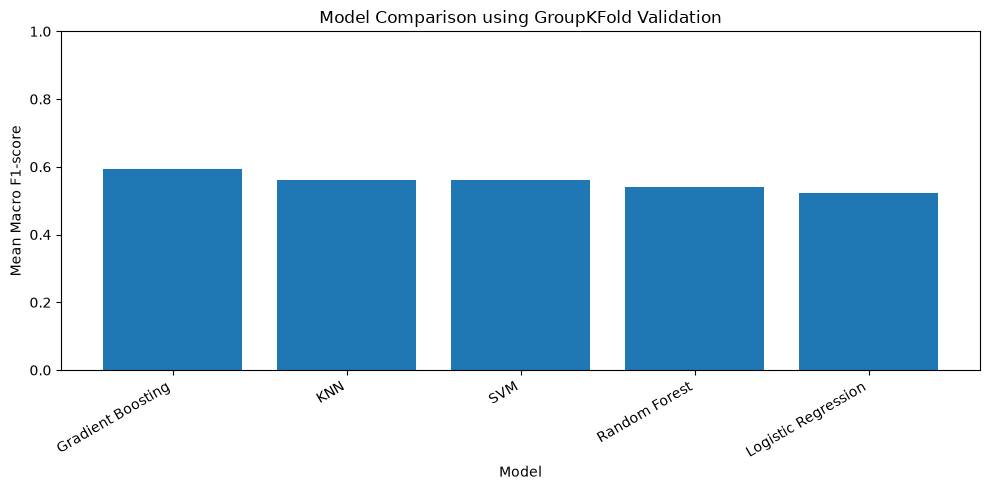

In [26]:
# Plot GroupKFold results because this is the stricter validation strategy.
plt.figure(figsize=(10, 5))
plt.bar(df_group_results["Model"], df_group_results["F1 Macro"])
plt.title("Model Comparison using GroupKFold Validation")
plt.xlabel("Model")
plt.ylabel("Mean Macro F1-score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("../outputs/plots/model_comparison_group_cv.png", dpi=300)
plt.show()

## 9. Final Model Analysis

Gradient Boosting achieved the best Macro F1-score under GroupKFold validation, so it is selected as the final model.

A group-based train/test split is used so that windows from the same EDF recording do not appear in both training and testing sets.

In [27]:
# Create a final train/test split grouped by EDF file.
groups = df_windows["file_name"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_window, y_window, groups=groups))

X_train, X_test = X_window.iloc[train_idx], X_window.iloc[test_idx]
y_train, y_test = y_window.iloc[train_idx], y_window.iloc[test_idx]

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training class distribution:")
print(y_train.value_counts())
print("Test class distribution:")
print(y_test.value_counts())

Training set shape: (2793, 75)
Test set shape: (714, 75)
Training class distribution:
label
1    2464
0     329
Name: count, dtype: int64
Test class distribution:
label
1    573
0    141
Name: count, dtype: int64


In [28]:
# Train the final Gradient Boosting model.
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(random_state=42))
])

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print("Final model trained.")

Final model trained.


In [29]:
# Print and save the final classification report.
report = classification_report(
    y_test,
    y_pred,
    target_names=["Non-stress", "Stress"],
    zero_division=0
)

print(report)

with open("../outputs/results/final_classification_report.txt", "w") as f:
    f.write(report)

              precision    recall  f1-score   support

  Non-stress       0.69      0.16      0.25       141
      Stress       0.83      0.98      0.90       573

    accuracy                           0.82       714
   macro avg       0.76      0.57      0.58       714
weighted avg       0.80      0.82      0.77       714



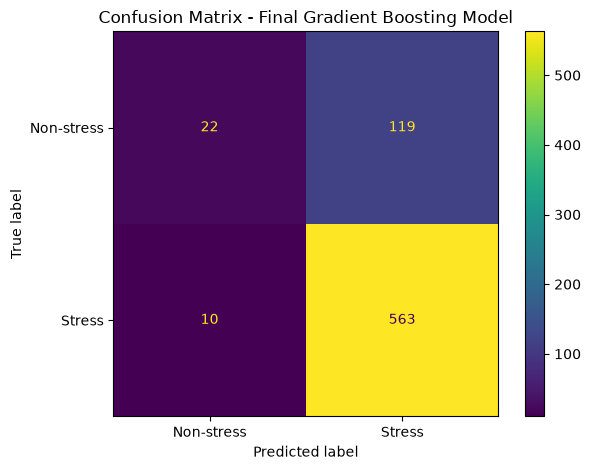

In [30]:
# Plot and save the confusion matrix.
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-stress", "Stress"]
)

disp.plot()
plt.title("Confusion Matrix - Final Gradient Boosting Model")
plt.tight_layout()
plt.savefig("../outputs/plots/confusion_matrix_final_model.png", dpi=300)
plt.show()

## 10. Feature Importance

Feature importance is extracted from the final Gradient Boosting model.
This helps identify which EEG features contributed most to the stress/non-stress classification decision.

In [31]:
# Create feature importance table from the trained Gradient Boosting model.
gb_model = final_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X_window.columns,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
74,AF4_gamma_power,0.259025
71,AF4_theta_power,0.068160
59,T8_gamma_power,0.058084
57,T8_alpha_power,0.040719
29,T7_gamma_power,0.040289
42,Pz_alpha_power,0.035515
43,Pz_beta_power,0.034345
64,AF4_max,0.032935
6,AF3_skew,0.031711
22,T7_kurtosis,0.031675


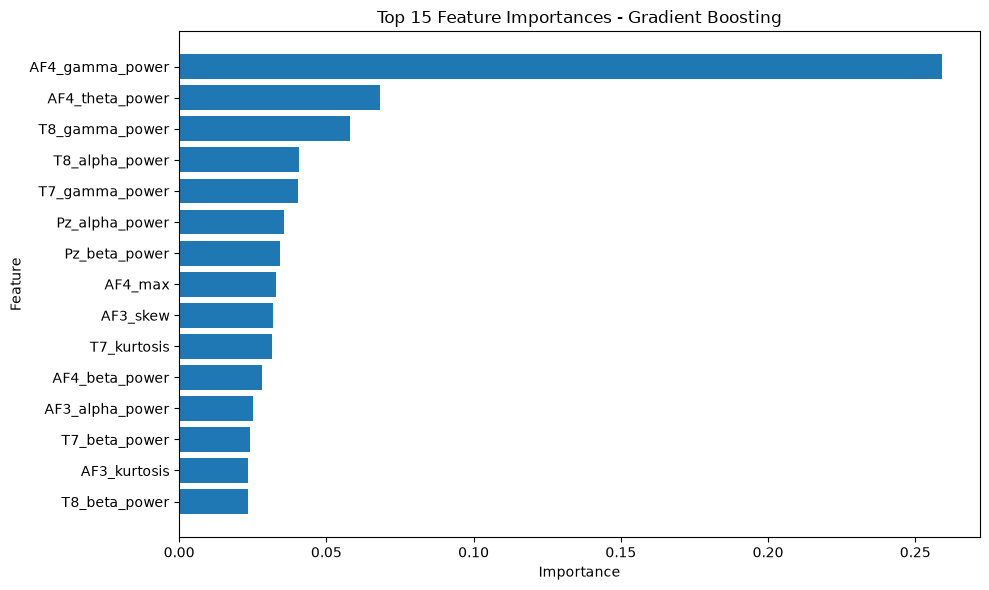

Feature importance table saved.


In [32]:
# Plot and save the top 15 most important features.
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../outputs/plots/feature_importance_final_model.png", dpi=300)
plt.show()

feature_importance.to_csv("../outputs/results/feature_importance_final_model.csv", index=False)
print("Feature importance table saved.")

## 11. Summary of Outputs

Running this notebook produces the following key output files:

**Plots**
- `class_distribution.png`
- `condition_distribution.png`
- `example_eeg_signal.png`
- `filtered_eeg_signal.png`
- `model_comparison_group_cv.png`
- `confusion_matrix_final_model.png`
- `feature_importance_final_model.png`

**Result tables**
- `eeg_features.csv`
- `eeg_window_features.csv`
- `model_comparison_window_random_cv.csv`
- `model_comparison_group_cv.csv`
- `final_classification_report.txt`
- `feature_importance_final_model.csv`

These outputs are used in the final report and final presentation.